# Netflix Movies Data Analysis

## Project Introduction

This project presents a comprehensive exploratory data analysis (EDA) of movies available on Netflix. The dataset contains valuable information about various movies, including their titles, genres, release years, popularity scores, vote counts and other relevant attributes.

### Objective
The main goal of this analysis is to uncover meaningful insights from the Netflix movie dataset that can help understand trends in movie production, genre popularity and audience engagement. These insights will support **informed business decisions** in content strategy and recommendation systems.

### Key Business Questions
This analysis aims to answer the following important questions:

1. What is the most frequent genre of movies released on Netflix?  
2. Which genre has the highest number of votes?  
3. What movie got the highest popularity? What is its genre?  
4. What movie got the lowest popularity? What is its genre?  
5. Which year has the most filmed movies?

### Approach
We will perform data cleaning, type conversion, exploratory data analysis and visualization to extract actionable insights from the dataset.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("mymoviedb.csv",lineterminator='\n')

In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
df.sample(5)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
2105,2009-05-01,Ghosts of Girlfriends Past,When notorious womanizer Connor Mead attends h...,39.329,1927,5.9,en,"Fantasy, Comedy, Romance",https://image.tmdb.org/t/p/original/yNn5NjNQF8...
7231,2018-12-28,Black Mirror: Bandersnatch,"In 1984, a young programmer begins to question...",16.351,3265,6.8,en,"Science Fiction, Mystery, Drama, Thriller, TV ...",https://image.tmdb.org/t/p/original/fR0VZ0VE59...
2769,1981-08-21,Private Lessons,"Phillip Filmore is a naive, 15-year-old, preoc...",32.076,67,5.7,en,"Comedy, Romance",https://image.tmdb.org/t/p/original/dTkBOgOv3t...
631,2017-06-16,Transformers: The Last Knight,"Autobots and Decepticons are at war, with huma...",89.866,4883,6.0,en,"Action, Adventure, Science Fiction, Fantasy",https://image.tmdb.org/t/p/original/s5HQf2Gb3l...
3506,2019-01-10,Polaroid,High school loner Bird Fitcher has no idea wha...,26.898,757,5.9,en,"Horror, Thriller, Mystery",https://image.tmdb.org/t/p/original/3ExDhZAqaS...


In [5]:
df.shape

(9827, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [7]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isna().sum()

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

In [10]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


### Exploration Summary: for Data Preprocessing

* we have dataset with `9827` rows and `9` columns.
* Dataset has `Duplicated` values
* Convert the `date` column from `object` data type to `datetime` for proper temporal analysis and operations.
* in dataset like, `Overview`,`Original_language` and `Postar_url` These columns are not relevant to the business questions being analyzed.
* there are noticeable can outlier in `Popularity` column.
* `Vote_Avarage` better be categorised for proper analysis.
* `Genre` Column has **Coma** Separated values with white space so we need to handle it.
* Remove `NaN` values in `Vote_Avarage` column.

In [11]:
df['Release_Date'].dtype

dtype('O')

### Convert Data type to datetime

In [12]:
df['Release_Date']=pd.to_datetime(df['Release_Date'])

print(df['Release_Date'].dtype)

datetime64[ns]


### Only Need year for analaysis, so keep only years

In [13]:
df['Release_Date'] = df['Release_Date'].dt.year

df['Release_Date'].dtypes

dtype('int32')

In [14]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


### Dropping the columns

In [15]:
cols=['Overview','Original_Language','Poster_Url']

In [16]:
df.drop(columns=cols,axis=1,inplace=True) # axis 1 means columns, 0 means row/index
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [17]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


### **Categorised `Vote_Average` column**
* Here we cut the `Vote_Average` columns and set 4 category like: **popular**, **average**, **below_avearge**, **not_popular**

In [18]:
# User define function for categorised
def categorised_col(df, col, labels):

    edges=[df[col].describe()['min'],
          df[col].describe()['25%'],
          df[col].describe()['50%'],
          df[col].describe()['75%'],
          df[col].describe()['max']]
    
    df[col]=pd.cut(x=df[col],bins=edges,labels=labels,duplicates='drop')
    return df

In [19]:
labels =['not_popular','below_average','average','popular']

In [20]:
categorised_col(df,'Vote_Average',labels)

df['Vote_Average'].unique()

['popular', 'below_average', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_average' < 'average' < 'popular']

In [21]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_average,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [22]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular      2467
popular          2450
average          2412
below_average    2398
Name: count, dtype: int64

In [23]:
df.isna().sum()

Release_Date      0
Title             0
Popularity        0
Vote_Count        0
Vote_Average    100
Genre             0
dtype: int64

### Here NaN value number is `100` which are too small compare to data shape, so drop those rows

In [24]:
df.dropna(inplace=True)

In [25]:
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [26]:
df.shape

(9727, 6)

### Handle `Genre` columns value

In [27]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_average,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


#### * Split Genre into list then, explode our data frame have only one genre per row for each movie

In [28]:
df['Genre']=df['Genre'].str.split(', ')

### What it does:
* Takes the 'Genre' column (which currently contains strings like "Action, Adventure, Sci-Fi")
* Uses .str.split(', ') to split each string on ", " (comma followed by space)
* Converts each value into a Python list

In [29]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"[Action, Adventure, Science Fiction]"
1,2022,The Batman,3827.658,1151,popular,"[Crime, Mystery, Thriller]"
2,2022,No Exit,2618.087,122,below_average,[Thriller]
3,2021,Encanto,2402.201,5076,popular,"[Animation, Comedy, Family, Fantasy]"
4,2021,The King's Man,1895.511,1793,average,"[Action, Adventure, Thriller, War]"


In [30]:
df = df.explode('Genre').reset_index(drop=True)

### What it does:

* df.explode('Genre') → Takes each list in the 'Genre' column and creates a new row for every item in that list.
* The other columns (like Title, Release_Date etc.) are duplicated for each exploded row.

In [31]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  object  
dtypes: category(1), float64(1), int32(1), int64(1), object(2)
memory usage: 923.6+ KB


In [34]:
# All Unique values according to columns 
df.nunique()

Release_Date     100
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

## Data Visualization -> It it important for each Question

In [35]:
# set style
sns.set_style("whitegrid")

## What is the most frequent genre of movies released on Netflix?

In [36]:
df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

<Figure size 1800x1400 with 0 Axes>

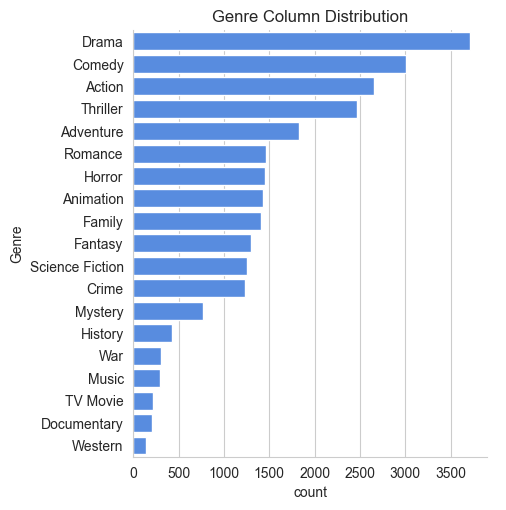

In [46]:
plt.figure(figsize=(18,14))
sns.catplot(data=df, y='Genre', order=df['Genre'].value_counts().index, kind='count', color='#4287f5')
plt.title("Genre Column Distribution")
plt.show()

## Which genre has the highest votes in vote Avg column?

In [47]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [48]:
df['Vote_Average'].describe()

count       25552
unique          4
top       average
freq         6613
Name: Vote_Average, dtype: object

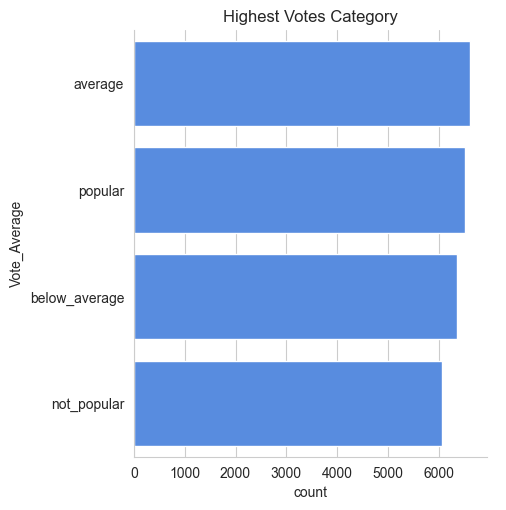

In [51]:
sns.catplot(data=df, y = 'Vote_Average', kind='count', order=df['Vote_Average'].value_counts().index, color='#4287f5')
plt.title("Highest Votes Category")
plt.show()

## What movie got the highest popularity? What is its genre?

In [52]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [62]:
df[df['Popularity']==df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


In [63]:
df[df['Popularity']==df['Popularity'].max()]['Genre']

0             Action
1          Adventure
2    Science Fiction
Name: Genre, dtype: object

## What movie got the lowest popularity? What is its genre?

In [65]:
df[df['Popularity']==df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,average,History
25549,1984,Threads,13.354,186,popular,War
25550,1984,Threads,13.354,186,popular,Drama
25551,1984,Threads,13.354,186,popular,Science Fiction


In [66]:
df[df['Popularity']==df['Popularity'].min()]['Genre']

25546              Music
25547              Drama
25548            History
25549                War
25550              Drama
25551    Science Fiction
Name: Genre, dtype: object

## Which year has the most filmed movies?

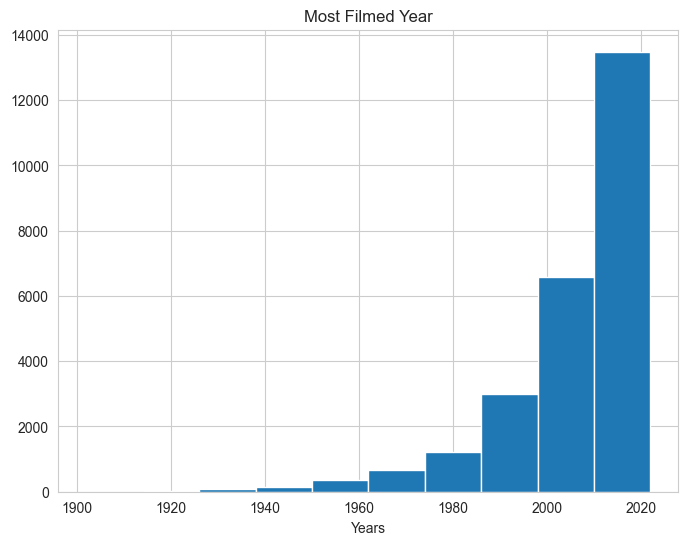

In [77]:
plt.figure(figsize=(8,6))
plt.hist(x=df['Release_Date'])
plt.title("Most Filmed Year")
plt.xlabel("Years")
plt.show()

# Conclusion

* ### Q1: What is the most frequent genre of movies released on Netflix?
  `Ans:` Drama Genre Has most frequent genre in our dataset it frequency is 3715.
* ### Q2: Which genre has the highest votes in vote Avg column?
  `Ans:` 